In [2]:
import numpy as np
import matplotlib.pyplot as plt
import yt
import units as un
import h5py
from scipy import stats

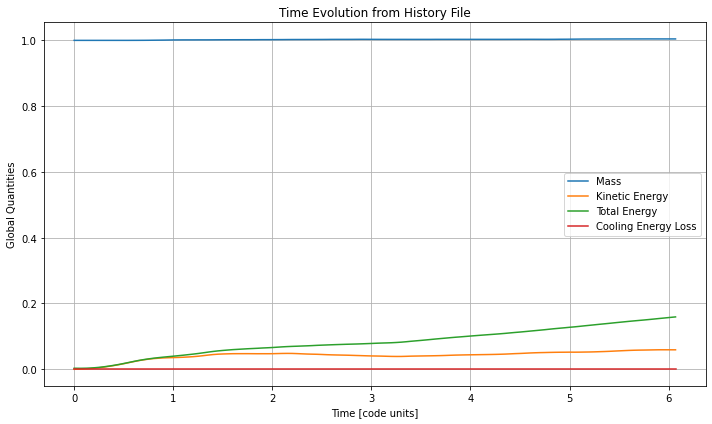

In [3]:

hst_file = "/ptmp/mpa/ankitad/athenapk/testrun/parthenon.out1.hst"

with open(hst_file, 'r') as f:
    lines = f.readlines()

header_line = next(line for line in lines if line.startswith("# [1]"))
headers = [entry.split('=')[1] for entry in header_line.strip('#').strip().split()]

data = np.loadtxt(hst_file)

col = {name: i for i, name in enumerate(headers)}

time = data[:, col['time']]
mass = data[:, col['mass']]
ke = data[:, col['KE']]
tot_e = data[:, col['tot-E']]
cool = data[:, col['DeltaEcool']]

plt.figure(figsize=(10, 6))
plt.plot(time, mass, label='Mass')
plt.plot(time, ke, label='Kinetic Energy')
plt.plot(time, tot_e, label='Total Energy')
plt.plot(time, cool, label='Cooling Energy Loss')

plt.xlabel('Time [code units]')
plt.ylabel('Global Quantities')
plt.title('Time Evolution from History File')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
def read_parthenon_data(filename):
    with h5py.File(filename, 'r') as f:
        prim_data = f['prim']
        
        if len(prim_data.shape) >= 2:
            n_vars = prim_data.shape[1] if len(prim_data.shape) > 1 else prim_data.shape[0]
            print(f"Number of variables: {n_vars}")
            if n_vars >= 5:
                rho = prim_data[..., 0]  # First component is density
                prs = prim_data[..., 4]  # Fifth component is pressure
                
                return rho, prs
            else:

                print("Please check your Parthenon configuration for variable ordering")
                # Try first and last components
                rho = prim_data[..., 0]
                prs = prim_data[..., -1]
                return rho, prs
        else:
            print("Unexpected array structure")
            return None, None

def fit_polytropic_relation(rho, prs, method='linear'):
    # Convert to log space
    log_rho = np.log10(rho)
    log_prs = np.log10(prs)
    
    if method == 'linear':
        # Linear fit in log space: log(P) = log(K) + gamma*log(rho)
        slope, intercept, r_value, p_value, std_err = stats.linregress(log_rho, log_prs)
        gamma_eff = slope
        log_K = intercept
        r_squared = r_value**2
        
    elif method == 'robust':
        # Use numpy polyfit with degree 1 (more robust to outliers)
        coeffs = np.polyfit(log_rho, log_prs, 1)
        gamma_eff = coeffs[0]
        log_K = coeffs[1]
        # Calculate R-squared manually
        log_prs_pred = gamma_eff * log_rho + log_K
        ss_res = np.sum((log_prs - log_prs_pred) ** 2)
        ss_tot = np.sum((log_prs - np.mean(log_prs)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
    
    K = 10**log_K
    
    # Generate fit line
    rho_fit = np.logspace(log_rho.min(), log_rho.max(), 100)
    prs_fit = K * rho_fit**gamma_eff
    
    return gamma_eff, K, rho_fit, prs_fit, r_squared


In [6]:

# Main execution
filename = "/ptmp/mpa/ankitad/athenapk/testrun/parthenon.prim.00025.phdf"
rho, prs = read_parthenon_data(filename)

Number of variables: 5


Density range: -6.60e-01 to 5.38e+01
Pressure range: -7.06e-01 to 9.41e+01
Temperature range: -3.16e+12 to 5.94e+12 K

Physical units:
Density: -1.10e-24 to 8.94e-23 g/cm^3
Pressure: -3.56e-22 to 4.75e-20 dyne/cm^2

Valid data points: 25025 out of 40960

Fitting polytropic relation P = K * ρ^γ...
Effective polytropic index: γ_eff = 0.807
Polytropic constant: K = 4.82e-03
R-squared: 0.638
Physical regime: Nearly isothermal


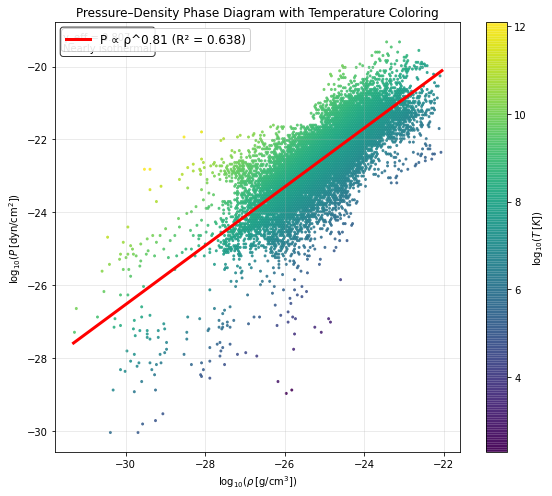

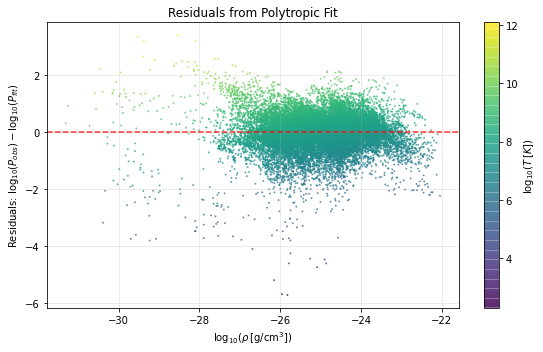

In [7]:


print(f"Density range: {rho.min():.2e} to {rho.max():.2e}")
print(f"Pressure range: {prs.min():.2e} to {prs.max():.2e}")

temp = un.temperature(rho, prs)
print(f"Temperature range: {temp.min():.2e} to {temp.max():.2e} K")

# Convert to physical units for plotting
rho_physical = rho * un.unit_density  # Convert to g/cm^3
prs_physical = prs * un.unit_q  # Convert to dyne/cm^2

print(f"\nPhysical units:")
print(f"Density: {rho_physical.min():.2e} to {rho_physical.max():.2e} g/cm^3")
print(f"Pressure: {prs_physical.min():.2e} to {prs_physical.max():.2e} dyne/cm^2")

# Flatten arrays for plotting (in case they're multidimensional)
rho_flat = rho_physical.flatten()
prs_flat = prs_physical.flatten()
temp_flat = temp.flatten()

# Remove any invalid values (zeros, infinities, etc.)
valid_mask = (rho_flat > 0) & (prs_flat > 0) & (temp_flat > 0) & np.isfinite(rho_flat) & np.isfinite(prs_flat) & np.isfinite(temp_flat)

rho_clean = rho_flat[valid_mask]
prs_clean = prs_flat[valid_mask]
temp_clean = temp_flat[valid_mask]

print(f"\nValid data points: {len(rho_clean)} out of {len(rho_flat)}")

if len(rho_clean) > 0:
    # Fit polytropic relation
    print("\nFitting polytropic relation P = K * ρ^γ...")
    gamma_eff, K, rho_fit, prs_fit, r_squared = fit_polytropic_relation(rho_clean, prs_clean, method='robust')
    
    print(f"Effective polytropic index: γ_eff = {gamma_eff:.3f}")
    print(f"Polytropic constant: K = {K:.2e}")
    print(f"R-squared: {r_squared:.3f}")
    
    # Interpret the polytropic index
    if gamma_eff < 1.1:
        regime = "Nearly isothermal"
    elif gamma_eff > 1.5:
        regime = "Nearly adiabatic"
    else:
        regime = "Mixed cooling/heating"
    print(f"Physical regime: {regime}")
    
    # Create the plot with fit line
    plt.figure(figsize=(8, 7))
    
    # Main scatter plot
    hb = plt.hexbin(np.log10(rho_clean), np.log10(prs_clean), 
                    C=np.log10(temp_clean),
                    gridsize=200, reduce_C_function=np.mean, cmap='viridis', 
                    alpha=0.8)
    
    # Add fit line
    plt.plot(np.log10(rho_fit), np.log10(prs_fit), 'r-', linewidth=3, 
                label=f'P ∝ ρ^{gamma_eff:.2f} (R² = {r_squared:.3f})')
    
    # Formatting
    plt.colorbar(hb, label=r'$\log_{10}(T\,[K])$')
    plt.xlabel(r'$\log_{10}(\rho\,[\mathrm{g/cm^3}])$')
    plt.ylabel(r'$\log_{10}(P\,[\mathrm{dyn/cm^2}])$')
    plt.title('Pressure–Density Phase Diagram with Temperature Coloring')
    plt.legend(loc='upper left', fontsize=12, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Add text box with physical interpretation
    textstr = f'γ_eff = {gamma_eff:.3f}\n{regime}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    plt.show()
    
    # Optional: Create a second plot showing residuals
    plt.figure(figsize=(8, 5))
    
    # Calculate residuals in log space
    log_rho_clean = np.log10(rho_clean)
    log_prs_clean = np.log10(prs_clean)
    log_prs_pred = np.log10(K) + gamma_eff * log_rho_clean
    residuals = log_prs_clean - log_prs_pred
    
    plt.scatter(log_rho_clean, residuals, c=np.log10(temp_clean), 
                cmap='viridis', alpha=0.6, s=1)
    plt.colorbar(label=r'$\log_{10}(T\,[K])$')
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.8)
    plt.xlabel(r'$\log_{10}(\rho\,[\mathrm{g/cm^3}])$')
    plt.ylabel(r'Residuals: $\log_{10}(P_{obs}) - \log_{10}(P_{fit})$')
    plt.title('Residuals from Polytropic Fit')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
else:
    print("No valid data points found for plotting!")
